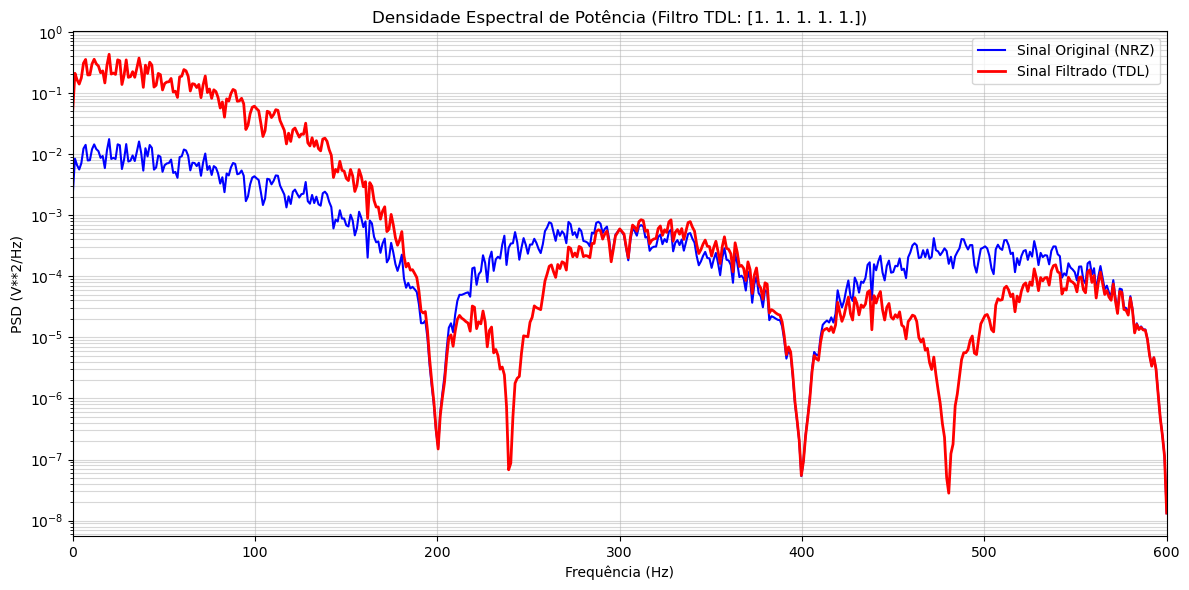

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --- Configurações Iniciais ---
fs = 1200              # Frequência de amostragem (Hz)
rb = 200               # Taxa de bits (Lóbulo principal em 200Hz)
n_bits = 1000          # Quantidade de bits para a densidade espectral
duration = n_bits / rb # Duração total em segundos

# --- 1. Geração do Sinal NRZ-L ---
bits = np.random.randint(0, 2, n_bits)
nrz = np.repeat(bits * 2 - 1, fs // rb) # Converte 0/1 para -1/1 e repete p/ fs
t = np.linspace(0, duration, len(nrz), endpoint=False)

# --- 2. Definição do Filtro TDL (5 Taps) ---
# Altere estes valores para ver diferentes comportamentos de filtragem
# Exemplo: [1, 1, 1, 1, 1] / 5 é um filtro média móvel (Passa-Baixas)
coefs = np.array([1.0, 1.0, 1.0, 1.0, 1.0]) 

# Aplicação do filtro via convolução (comportamento do TDL)
nrz_filtrado = signal.lfilter(coefs, 1, nrz)

# --- 3. Cálculo da Densidade Espectral de Potência (PSD) ---
freqs_orig, psd_orig = signal.welch(nrz, fs, nperseg=1024)
freqs_filt, psd_filt = signal.welch(nrz_filtrado, fs, nperseg=1024)

# --- 4. Visualização ---
plt.figure(figsize=(12, 6))

# Plot da PSD
plt.semilogy(freqs_orig, psd_orig, label='Sinal Original (NRZ)', color='blue')
plt.semilogy(freqs_filt, psd_filt, label='Sinal Filtrado (TDL)', color='red', linewidth=2)

plt.title(f'Densidade Espectral de Potência (Filtro TDL: {coefs})')
plt.xlabel('Frequência (Hz)')
plt.ylabel('PSD (V**2/Hz)')
plt.xlim(0, 600) # Foco de 0 a 600 Hz conforme solicitado
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()